## Molecular Position Effect on Bayer-Detector Images

For ATTO 488, ATTO 565, and ATTO 647N, renders noiseless simulated images on the
Ximea Bayer detector across a 5×5 grid of sub-pixel positions spanning **one
2×2 unit cell** in both X and Y.

Layout of each figure (6×6 GridSpec):
- **Top row** (row 0, cols 1–5): the 2×2 Bayer unit cell repeated to 4×4 pixels,
  with a white dashed **vertical** line at each column's Y sub-pixel position.
- **Left col** (col 0, rows 1–5): the 2×2 unit cell with a white dashed
  **horizontal** line at each row's X sub-pixel position.
- **Inner 5×5**: simulated Bayer images at each (X, Y) combination.

Reading across a row shows the effect of changing Y position at fixed X;
reading down a column shows the effect of changing X at fixed Y.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import types
from pathlib import Path
import sys

from pyS3M import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from pyS3M.PlottingBase import plot_bayer_pattern
from pyS3M.Multicolour_Simulation_Functions import MultiC_Sim_Funcs

IO      = IOFunctions.IO_Functions()
S_F     = SpectralFunctions.Spectral_Funcs()
M_F     = MaskFunctions.Mask_Functions()
sCMOS   = sCMOSFunctions.sCMOS_Functions()
MSF     = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

smoothing_function = types.SimpleNamespace(
    args={'sigma': 1.5},
    extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack,
    data_arg='image',
)

In [2]:
# ── Camera calibration ────────────────────────────────────────────────────────
data_folder = '../../../Camera_Calibrations/Ximea_Camera/'
gain      = IO.read_tiff(os.path.join(data_folder, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(data_folder, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(data_folder, 'variance.tif'))
readnoise = float(np.median(IO.read_tiff(os.path.join(data_folder, 'readnoise.tif'))))
rqe       = IO.read_tiff(os.path.join(data_folder, 'rqe.tif'))
print(f'Sensor: {gain.shape}  readnoise: {readnoise:.2f}')

Sensor: (1544, 2064)  readnoise: 2.34


In [3]:
# ── Spectral setup ────────────────────────────────────────────────────────────
R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_base, G_base, R_base])   # B=0, G=1, R=2

dyes    = ['ATTO 488', 'ATTO 565', 'ATTO 647N']
filters = []
NA           = 1.49
pixel_size   = 69.0      # nm
image_size   = 14        # pixels
n_photon     = 4000
n_background = 4

In [4]:
# ── Camera parameters ─────────────────────────────────────────────────────────
camera_params = {
    'gain':               np.full((image_size, image_size), np.median(gain)),
    'offset':             np.full((image_size, image_size), np.median(offset)),
    'variance':           np.full((image_size, image_size), np.median(variance)),
    'readnoise':          readnoise,
    'rqe':                np.full((image_size, image_size), np.median(rqe)),
    'masks':              M_F.get_masks(size_x=image_size, size_y=image_size),
    'pixel_QYs':          pixel_QYs,
    'pixel_order':        ['B', 'G', 'R'],
    'pixel_order_indices': {'B': 0, 'G': 1, 'R': 2},
}

In [5]:
# ── Position grid spanning exactly one 2×2 Bayer unit cell ───────────────────
# Start at pixel 6 (even → aligns with B corner of BGGR unit cell).
# linspace(6, 8, 5) gives positions [6.0, 6.5, 7.0, 7.5, 8.0] pixels from origin,
# which spans one full unit cell: B→mid→G→mid→B(next).
n_grid = 5
center_start_px = 6   # even pixel — unit-cell corner

x0r_nm = np.linspace(center_start_px, center_start_px + 2, n_grid) * pixel_size
y0r_nm = np.linspace(center_start_px, center_start_px + 2, n_grid) * pixel_size

# Unit-cell pixel offsets [0, 0.5, 1.0, 1.5, 2.0]  (for border panel lines)
unit_cell_pos = np.linspace(0.25, 1.75, n_grid)
# Shift by +1 so lines appear centred in the size=4 border display
border_vlines = unit_cell_pos  # for top-row panels (Y position)
border_hlines = unit_cell_pos   # for left-col panels (X position)

print(f'X positions (nm): {x0r_nm}')
print(f'Y positions (nm): {y0r_nm}')
print(f'Unit-cell offsets (px): {unit_cell_pos}')

X positions (nm): [ 414.   448.5  483.   517.5  552. ]
Y positions (nm): [ 414.   448.5  483.   517.5  552. ]
Unit-cell offsets (px): [ 0.25   0.625  1.     1.375  1.75 ]


In [6]:
# ── Generate 5×5 images per dye ───────────────────────────────────────────────
# ix (row index) varies slowest → corresponds to X position.
# iy (col index) varies fastest → corresponds to Y position.
ix_flat = np.repeat(np.arange(n_grid), n_grid)   # [0,0,0,0,0, 1,1,...]
iy_flat = np.tile(np.arange(n_grid), n_grid)     # [0,1,2,3,4, 0,1,...]
x_flat_nm = x0r_nm[ix_flat]
y_flat_nm = y0r_nm[iy_flat]
n_pos = n_grid * n_grid

images_grid = {}   # dye → (n_grid, n_grid, image_size, image_size)

for dye in dyes:
    aew, dpe = S_F.get_pixel_fractions_dye_and_filters(
        [dye], filters, wavelength, pixel_QYs
    )
    n_photons_dict = {dye: np.full(n_pos, n_photon)}
    x0y0 = {dye: np.zeros([n_pos, 2, 1])}
    x0y0[dye][:, 0, 0] = y_flat_nm   # first coord = y (row)
    x0y0[dye][:, 1, 0] = x_flat_nm   # second coord = x (col)

    imgs, _, _ = MSF.gen_camera_image_stack(
        camera_params, wavelength,
        np.array(aew), np.array(dpe),
        n_photons_dict, x0y0,
        background_photons=n_background,
        smoothing_function=smoothing_function,
        NA=NA, pixel_size=pixel_size,
        return_normal_image=False,
    )
    images_grid[dye] = imgs.reshape(n_grid, n_grid, image_size, image_size)
    print(f'{dye}: {images_grid[dye].shape}')

print('Done.')

ATTO 488: (5, 5, 14, 14)
ATTO 565: (5, 5, 14, 14)
ATTO 647N: (5, 5, 14, 14)
Done.


## Fitting statistics across Bayer positions

Run 10 000 STANDARD_ITER simulations at each of the 25 sub-pixel positions to verify that
fitted colour ratios (A_B, A_G, A_R) and localisation residuals are invariant to the
molecule's position within the Bayer unit cell.

In [7]:
# ── Run 10 000 simulations at each of the 25 positions ───────────────────────
# Import from src.Multicolour_Simulation_Functions so FittingStrategy, CameraParameters
# and SimulationConfig are the same module instances that MSF uses internally — avoids
# the double-import enum identity mismatch that occurs with src.simulation.multicolour.
from pyS3M.Multicolour_Simulation_Functions import FittingStrategy, CameraParameters, SimulationConfig

strategy       = FittingStrategy.STANDARD_ITER
n_sim          = 10000
n_photon_sim   = 1000
bg_photons_sim = 10

config_sim = SimulationConfig(
    n_bootstrap=n_sim,
    background_photons=bg_photons_sim,
    NA=NA,
    pixel_size=pixel_size,
    verbose=False,
    save_raw_results=False,
    save_summary_csvs=False,
)

cam_params_dc = CameraParameters.validate_and_create(camera_params)

# colour_results[dye]: (n_grid, n_grid, n_sim, 3)  — A_B, A_G, A_R per fit
# pos_results[dye]:    (n_grid, n_grid, n_sim, 2)  — xc_residual, yc_residual in nm
colour_results = {}
pos_results    = {}

for dye in dyes:
    dye_spectrum = S_F.get_dye_or_filter_data(
        names=[dye], wavelength=wavelength, dye_or_filter=True
    )[0]

    A_stack   = np.full((n_grid, n_grid, n_sim, 3), np.nan)
    pos_stack = np.full((n_grid, n_grid, n_sim, 2), np.nan)

    for ix in range(n_grid):
        for iy in range(n_grid):
            x0 = x0r_nm[ix]
            y0 = y0r_nm[iy]

            # Stochastic per-frame colour ratios (realistic photon shot noise)
            aew_s, dpe_s = S_F.generate_bootstrap_colour_ratios(
                dye_spectrum, wavelength, pixel_QYs,
                n_photons_per_image=n_photon_sim,
                n_bootstrap=n_sim,
                pixel_order=['B', 'G', 'R'],
                pixel_order_indices={'B': 0, 'G': 1, 'R': 2},
            )

            x0y0_s = {'sim': np.zeros([n_sim, 2, 1])}
            x0y0_s['sim'][:, :, :] = np.array([[x0, y0]]).T
            n_photons_s = {'sim': np.full(n_sim, n_photon_sim)}

            bayer_image, smoothed_image, _ = MSF.gen_camera_image_stack(
                camera_params, wavelength,
                aew_s, dpe_s,
                n_photons_s, x0y0_s,
                smoothing_function=smoothing_function,
                background_photons=bg_photons_sim,
                NA=NA, pixel_size=pixel_size,
                return_normal_image=False,
            )

            pe_data, sm_data, gs_data = MSF._prepare_fitting_data(
                bayer_image, smoothed_image, cam_params_dc, strategy, config_sim
            )
            weights_map, _ = MSF._compute_error_maps(sm_data, None, cam_params_dc)
            fit_df = MSF._perform_fitting(
                strategy, pe_data, sm_data, weights_map,
                gs_data, cam_params_dc, config_sim
            )

            n_fit = len(fit_df)
            A_stack[ix, iy, :n_fit, 0] = fit_df['A_B'].to_numpy()
            A_stack[ix, iy, :n_fit, 1] = fit_df['A_G'].to_numpy()
            A_stack[ix, iy, :n_fit, 2] = fit_df['A_R'].to_numpy()
            pos_stack[ix, iy, :n_fit, 0] = (fit_df['xc'].to_numpy() - x0 / pixel_size) * pixel_size
            pos_stack[ix, iy, :n_fit, 1] = (fit_df['yc'].to_numpy() - y0 / pixel_size) * pixel_size

        print(f'  {dye}  row {ix + 1}/{n_grid}')

    colour_results[dye] = A_stack
    pos_results[dye]    = pos_stack
    print(f'{dye}: complete')

print('All simulations done.')

  ATTO 488  row 1/5                                                                                                                                                                                                                          ?, ?it/s]
  ATTO 488  row 2/5                                                                                                                                                                                                                          ?, ?it/s]
  ATTO 488  row 3/5                                                                                                                                                                                                                          ?, ?it/s]
  ATTO 488  row 4/5                                                                                                                                                                                                                          ?, ?it/s]
  ATTO 488  

In [8]:
# ── Save folder ───────────────────────────────────────────────────────────────
save_folder = Path('/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Position_vs_Fit')
save_folder.mkdir(parents=True, exist_ok=True)
print(f'Saving to: {save_folder}')

Saving to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Position_vs_Fit


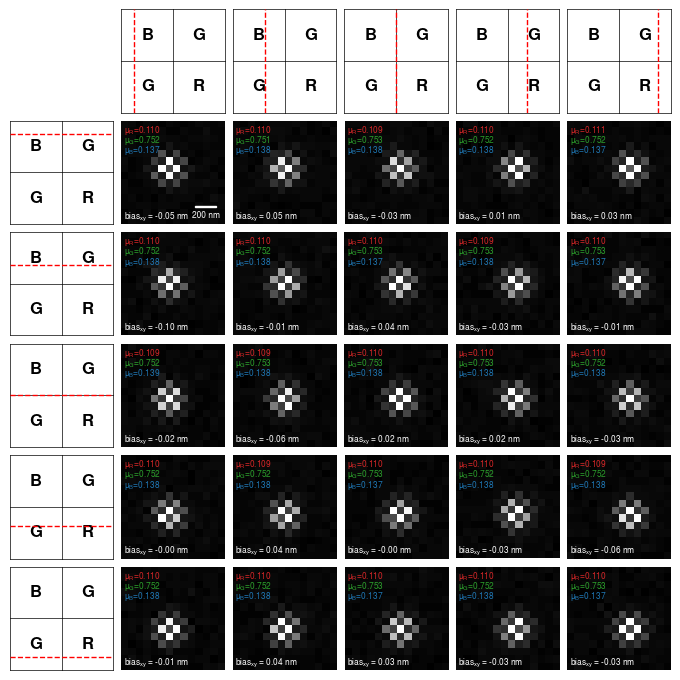

Saved: ATTO_488_position_grid_new.svg


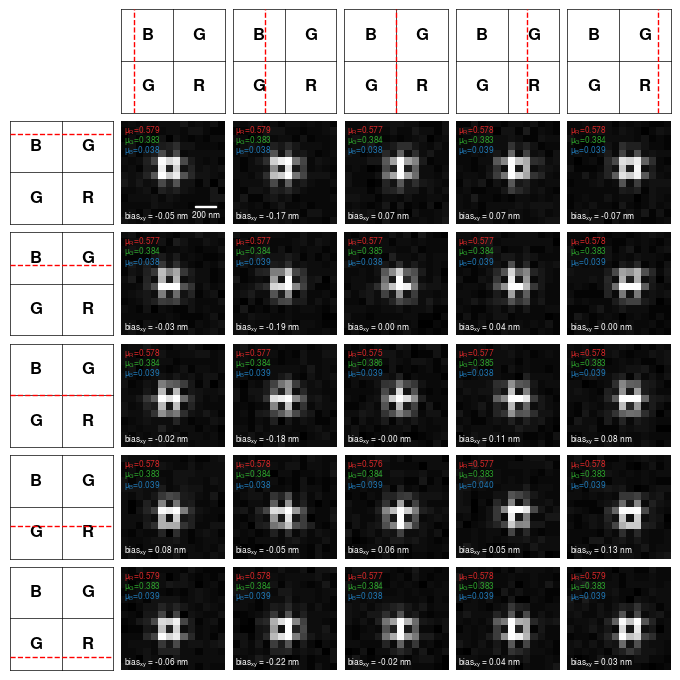

Saved: ATTO_565_position_grid_new.svg


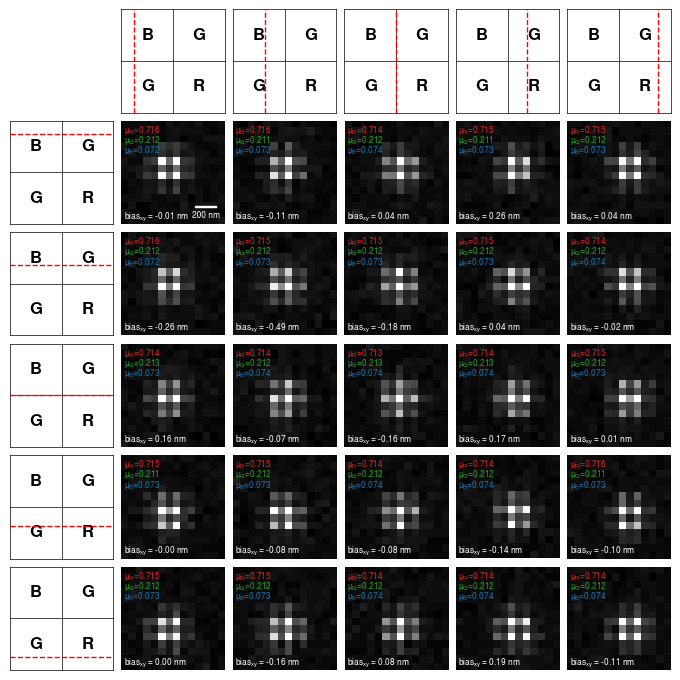

Saved: ATTO_647N_position_grid_new.svg


In [10]:
# ── Plot 5×5 position grid for each dye ──────────────────────────────────────
# GridSpec(6, 6): row/col 0 = border panels (same size as images); rows/cols 1–5 = images.
# Border panels: 4×4 Bayer pattern (2×2 unit cells), dark_background=False, red position line.
# First image [1,1]: scale bar added. All images: per-dye vmin/vmax (1st–99th percentile).
# Each inner panel also gets annotations from the fitting-stats simulation above:
# top-left = per-channel mu of the fitted colour fraction (R, G, B -- colour-coded);
# bottom-left = bias_xy (mean of the x and y position-residual biases) in white.
# Plain unicode text (not mathtext) is used throughout so mu/R/G/B render upright,
# not italicised.

for dye in dyes:
    imgs = images_grid[dye]   # (5, 5, 14, 14)
    A    = colour_results[dye]   # (5, 5, n_sim, 3) -- B, G, R order
    P    = pos_results[dye]      # (5, 5, n_sim, 2) -- x, y residual (nm)
    vmin = float(np.percentile(imgs, 1))
    vmax = float(np.percentile(imgs, 99))

    fig = plt.figure(layout='constrained', figsize=(6.69, 6.69))
    gs = GridSpec(
        n_grid + 1, n_grid + 1, figure=fig,
        width_ratios=[1.0] * (n_grid + 1),
        height_ratios=[1.0] * (n_grid + 1),
    )

    for i in range(n_grid + 1):
        for j in range(n_grid + 1):
            ax = fig.add_subplot(gs[i, j])

            if i == 0 and j == 0:
                ax.axis('off')

            elif i == 0:
                # Top border: Bayer pattern with vertical line at Y sub-pixel position
                plot_bayer_pattern(
                    ax=ax, pattern='BGGR', size=2,
                    vline=border_vlines[j - 1],
                    fontsize=12,
                    dark_background=False,
                    line_color='red',
                )

            elif j == 0:
                # Left border: Bayer pattern with horizontal line at X sub-pixel position
                plot_bayer_pattern(
                    ax=ax, pattern='BGGR', size=2,
                    hline=border_hlines[i - 1],
                    fontsize=12,
                    dark_background=False,
                    line_color='red',
                )

            else:
                # Inner 5×5: rendered Bayer image at (x=x0r[i-1], y=y0r[j-1])
                is_first = (i == 1 and j == 1)
                plotter.image_plot(
                    ax,
                    imgs[i - 1, j - 1, :, :].T,
                    cmap='gray',
                    vmin=vmin, vmax=vmax,
                    colorbar=False,
                    scalebar=is_first,
                    pixelsize=pixel_size,
                    scalebarsize=200,
                    scalebarlabel='200 nm',
                    origin='upper',
                )

                # ── 4 annotation lines: mu/sigma per channel (R, G, B), then
                # bias_xy in white -- computed from the fitting-stats simulation.
                ix_, iy_ = i - 1, j - 1
                mu_B, sig_B = np.nanmean(A[ix_, iy_, :, 0]), np.nanstd(A[ix_, iy_, :, 0])
                mu_G, sig_G = np.nanmean(A[ix_, iy_, :, 1]), np.nanstd(A[ix_, iy_, :, 1])
                mu_R, sig_R = np.nanmean(A[ix_, iy_, :, 2]), np.nanstd(A[ix_, iy_, :, 2])
                bias_x = np.nanmean(P[ix_, iy_, :, 0])
                bias_y = np.nanmean(P[ix_, iy_, :, 1])
                bias_xy = np.mean([bias_x, bias_y])

                # R/G/B mu lines, top-left. \mathrm{} keeps mathtext upright (not
                # italic, mathtext's default for bare variables), and mathtext's
                # own "_" gives a true (lowered) subscript -- PlottingBase configures
                # mathtext.fontset='custom' pointed at the same resolved sans-serif
                # font used for plain text, so this matches Helvetica/its fallback too.
                rgb_lines = [
                    (r'$\mathrm{\mu_R}$=' + f'{mu_R:.3f}', 'tab:red'),
                    (r'$\mathrm{\mu_G}$=' + f'{mu_G:.3f}', 'tab:green'),
                    (r'$\mathrm{\mu_B}$=' + f'{mu_B:.3f}', 'tab:blue'),
                ]
                for k, (text, color) in enumerate(rgb_lines):
                    ax.text(0.02, 0.98 - k * 0.10, text, transform=ax.transAxes,
                            fontsize=6, color=color, ha='left', va='top')

                # bias_xy line, separated out, bottom-left
                ax.text(0.02, 0.02, r'bias$\mathrm{_{xy}}$ = ' + f'{bias_xy:.2f} nm',
                        transform=ax.transAxes, fontsize=6, color='white',
                        ha='left', va='bottom')

    fname = f"{dye.replace(' ', '_')}_position_grid_new.svg"
    fig.savefig(str(save_folder / fname), format='svg', dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

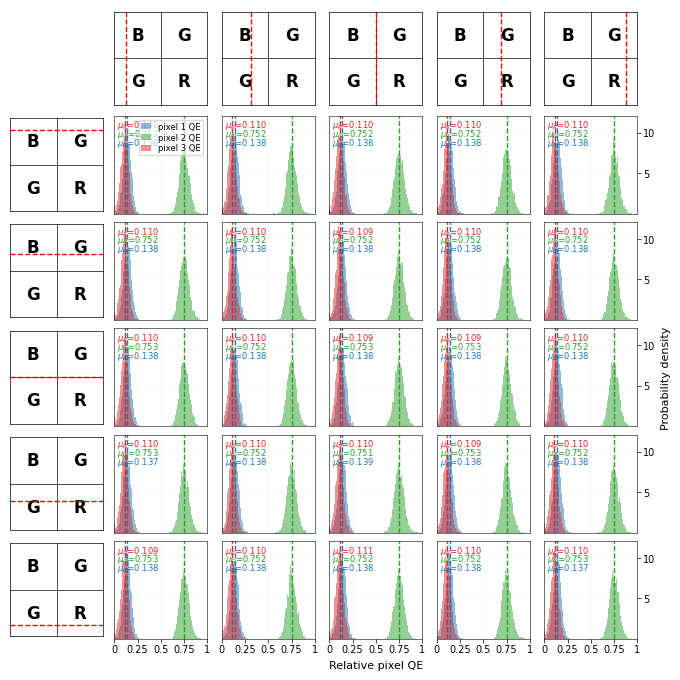

Saved: ATTO_488_colour_histogram_grid.svg


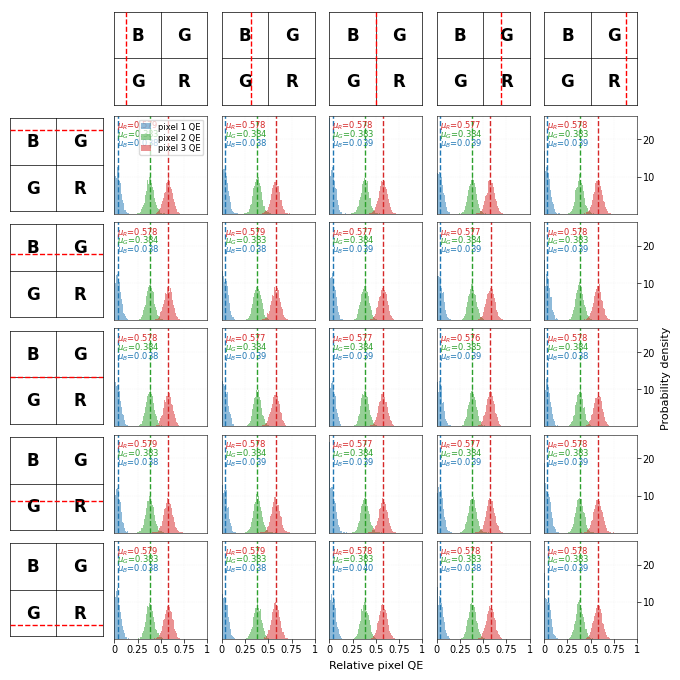

Saved: ATTO_565_colour_histogram_grid.svg


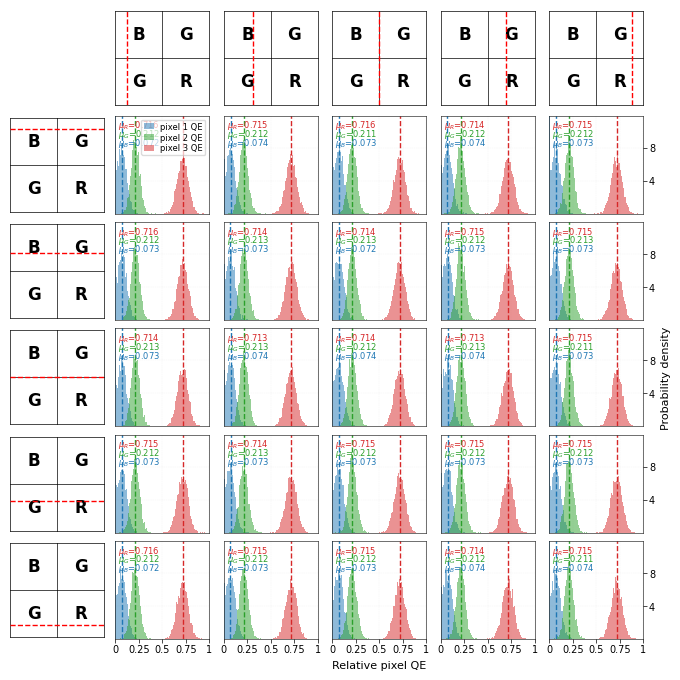

Saved: ATTO_647N_colour_histogram_grid.svg


In [14]:
# ── Colour-ratio histogram grid ───────────────────────────────────────────────
# All inner panels share:
#   X gridlines at 0, 0.25, 0.5, 0.75, 1  (tick marks + labels only on bottom row)
#   Y gridlines at shared MaxNLocator ticks (tick marks + labels only on rightmost column, right side)
# Legend key in the top-left histogram panel [i=1, j=1].

ch_colors  = ['tab:blue', 'tab:green', 'tab:red']
ch_labels  = ['pixel 1 QE', 'pixel 2 QE', 'pixel 3 QE']
hist_bins  = 100
x_ticks    = [0, 0.25, 0.5, 0.75, 1]
xlim       = (0.0, 1.0)   # colour ratios are normalised fractions

for dye in dyes:
    A = colour_results[dye]   # (5, 5, n_sim, 3)

    # Global y limit from all panels
    max_density = 0.0
    for ix in range(n_grid):
        for iy in range(n_grid):
            for ch in range(3):
                counts, _ = np.histogram(
                    A[ix, iy, :, ch][np.isfinite(A[ix, iy, :, ch])],
                    bins=hist_bins, range=xlim, density=True,
                )
                max_density = max(max_density, float(counts.max()))
    ylim = (0, max_density * 1.15)

    # Shared y-tick positions so gridlines align across all panels
    yticks_shared = plt.MaxNLocator(3, prune='both').tick_values(ylim[0], ylim[1])

    fig = plt.figure(layout='constrained', figsize=(6.69, 6.69))
    gs  = GridSpec(
        n_grid + 1, n_grid + 1, figure=fig,
        width_ratios=[1.0] * (n_grid + 1),
        height_ratios=[1.0] * (n_grid + 1),
    )

    for i in range(n_grid + 1):
        for j in range(n_grid + 1):
            ax = fig.add_subplot(gs[i, j])

            if i == 0 and j == 0:
                ax.axis('off')

            elif i == 0:
                plot_bayer_pattern(
                    ax=ax, pattern='BGGR', size=2,
                    vline=border_vlines[j - 1],
                    fontsize=12, dark_background=False, line_color='red',
                )

            elif j == 0:
                plot_bayer_pattern(
                    ax=ax, pattern='BGGR', size=2,
                    hline=border_hlines[i - 1],
                    fontsize=12, dark_background=False, line_color='red',
                )

            else:
                ix_, iy_ = i - 1, j - 1
                for ch, (col, lbl) in enumerate(zip(ch_colors, ch_labels)):
                    vals = A[ix_, iy_, :, ch]
                    vals = vals[np.isfinite(vals)]
                    ax = plotter.histogram_plot(ax, vals, bins=hist_bins,
                            density=True, color=col, alpha=0.5, label=lbl)
                    ax.vlines(x=np.median(vals), ls='--', lw=1, color=col,
                              ymin=0, ymax=ylim[-1])

                # ── 3 annotation lines: mu/sigma per channel (R, G, B) ────────
                for k, (ch, lbl, col) in enumerate(
                    [(2, 'R', 'tab:red'), (1, 'G', 'tab:green'), (0, 'B', 'tab:blue')]
                ):
                    vals = A[ix_, iy_, :, ch]
                    vals = vals[np.isfinite(vals)]
                    mu, sig = np.mean(vals), np.std(vals)
                    ax.text(0.03, 0.97 - k * 0.09,
                            rf'$\mu_{{{lbl}}}$={mu:.3f}',
                            transform=ax.transAxes, fontsize=6, color=col, ha='left', va='top')

                ax.set_xlim(xlim)
                ax.set_ylim(ylim)
                ax.set_axisbelow(True)

                # ── X axis: fixed ticks + gridlines on every panel ───────────
                ax.set_xticks(x_ticks)
                ax.grid(True, axis='x', linewidth=0.3, color='lightgray', zorder=0)
                if i == n_grid:
                    ax.set_xticklabels(['0', '0.25', '0.5', '0.75', '1'])
                    ax.tick_params(axis='x', bottom=True, labelbottom=True,
                                   labelsize=7, pad=1, length=3)
                    if j == 3:
                        ax.set_xlabel('Relative pixel QE', fontsize=8)
                    else:
                        ax.set_xlabel('')
                else:
                    # keep tick positions for gridlines, hide marks and labels
                    ax.tick_params(axis='x', bottom=False, labelbottom=False, length=0)
                    ax.set_xlabel('')

                # ── Y axis: shared ticks + gridlines on every panel ──────────
                ax.set_yticks(yticks_shared)
                ax.grid(True, axis='y', linewidth=0.3, color='lightgray', zorder=0)
                if j == n_grid:
                    ax.yaxis.tick_right()
                    ax.yaxis.set_label_position('right')
                    ax.tick_params(axis='y', right=True, labelright=True,
                                   left=False, labelleft=False,
                                   labelsize=7, pad=1, length=3)
                    if i == 3:
                        ax.set_ylabel('Probability density', fontsize=8)
                    else:
                        ax.set_ylabel('')
                else:
                    # keep tick positions for gridlines, hide marks and labels
                    ax.tick_params(axis='y', left=False, right=False,
                                   labelleft=False, labelright=False, length=0)
                    ax.set_ylabel('')

                # Legend only in top-left histogram panel
                if i == 1 and j == 1:
                    ax.legend(fontsize=6, loc='upper right', framealpha=0.7,
                              handlelength=1.2, borderpad=0.3, labelspacing=0.2)
                else:
                    leg = ax.get_legend()
                    if leg is not None:
                        leg.remove()

                for spine in ax.spines.values():
                    spine.set_linewidth(0.4)

    fname = f"{dye.replace(' ', '_')}_colour_histogram_grid.svg"
#    fig.savefig(str(save_folder / fname), format='svg', dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

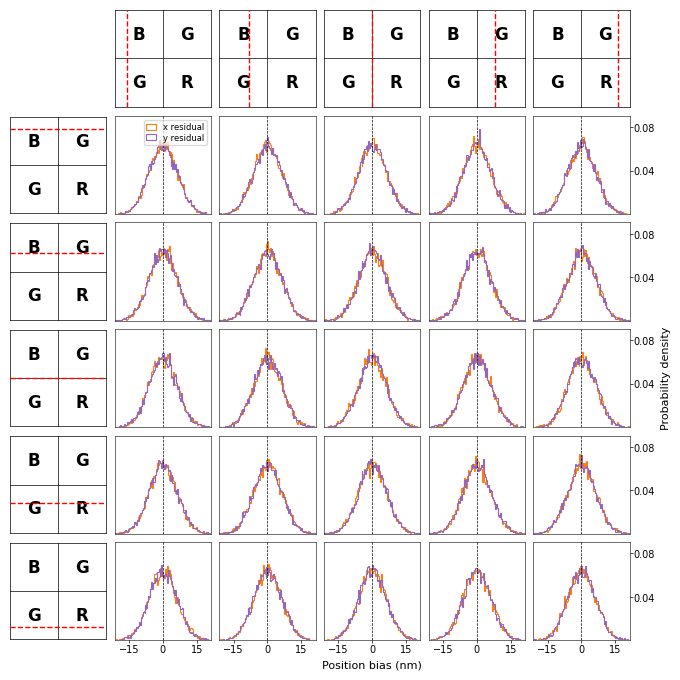

Saved: ATTO_488_position_bias_grid.svg


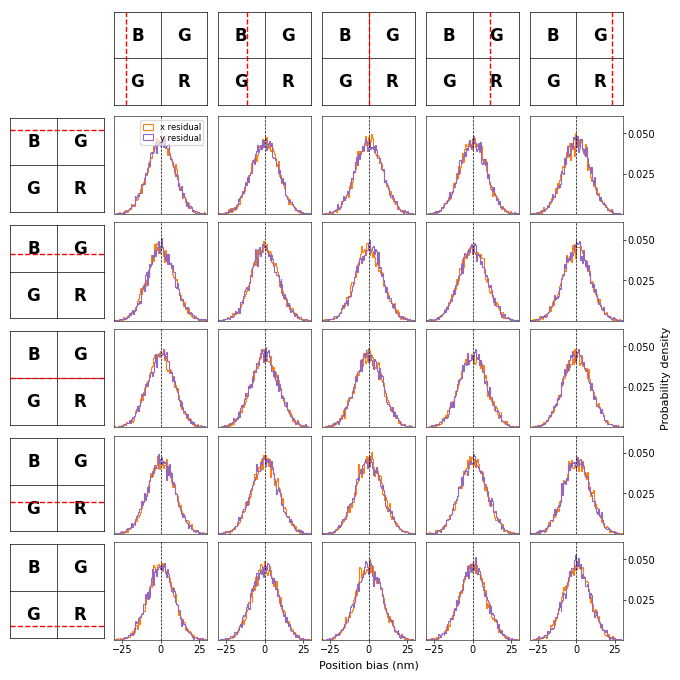

Saved: ATTO_565_position_bias_grid.svg


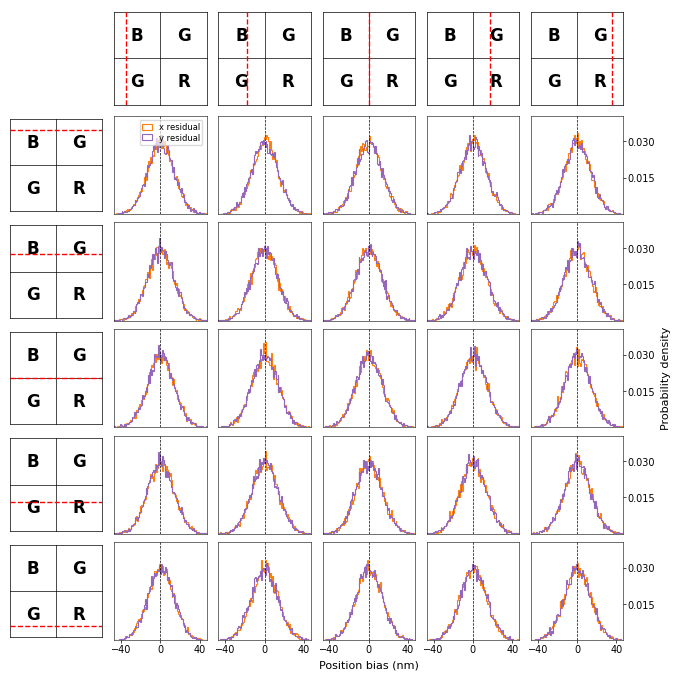

Saved: ATTO_647N_position_bias_grid.svg


In [12]:
# ── Position-bias histogram grid ─────────────────────────────────────────────
# Outer axes: probability density on rightmost histogram column (j=n_grid, right side);
#             "Position bias (nm)" on bottom histogram row (i=n_grid).
# Legend key in the top-left histogram panel [i=1, j=1].

pos_colors = ['tab:orange', 'tab:purple']
pos_labels = ['x residual', 'y residual']

for dye in dyes:
    P = pos_results[dye]   # (5, 5, n_sim, 2)

    valid_abs = np.abs(P[np.isfinite(P)])
    lim  = float(np.nanpercentile(valid_abs, 99.5)) * 1.2
    xlim = (-lim, lim)

    max_density = 0.0
    for ix in range(n_grid):
        for iy in range(n_grid):
            for ax_idx in range(2):
                vals = P[ix, iy, :, ax_idx]
                vals = vals[np.isfinite(vals)]
                counts, _ = np.histogram(vals, bins=hist_bins, range=xlim, density=True)
                max_density = max(max_density, float(counts.max()))
    ylim = (0, max_density * 1.15)

    fig = plt.figure(layout='constrained', figsize=(6.69, 6.69))
    gs  = GridSpec(
        n_grid + 1, n_grid + 1, figure=fig,
        width_ratios=[1.0] * (n_grid + 1),
        height_ratios=[1.0] * (n_grid + 1),
    )

    for i in range(n_grid + 1):
        for j in range(n_grid + 1):
            ax = fig.add_subplot(gs[i, j])

            if i == 0 and j == 0:
                ax.axis('off')

            elif i == 0:
                plot_bayer_pattern(
                    ax=ax, pattern='BGGR', size=2,
                    vline=border_vlines[j - 1],
                    fontsize=12, dark_background=False, line_color='red',
                )

            elif j == 0:
                plot_bayer_pattern(
                    ax=ax, pattern='BGGR', size=2,
                    hline=border_hlines[i - 1],
                    fontsize=12, dark_background=False, line_color='red',
                )

            else:
                ix_, iy_ = i - 1, j - 1
                for ax_idx, (col, lbl) in enumerate(zip(pos_colors, pos_labels)):
                    vals = P[ix_, iy_, :, ax_idx]
                    vals = vals[np.isfinite(vals)]
                    ax.hist(vals, bins=hist_bins, range=xlim,
                            density=True, histtype='step',
                            color=col, linewidth=0.8, label=lbl)
                ax.axvline(0, color='k', linewidth=0.5, linestyle='--')

                # ── 2 annotation lines: bias_x and bias_y, kept separate ──────
                for k, (ax_idx, lbl, col) in enumerate(zip([0, 1], ['x', 'y'], pos_colors)):
                    vals = P[ix_, iy_, :, ax_idx]
                    vals = vals[np.isfinite(vals)]
                    bias = np.mean(vals)

                ax.set_xlim(xlim)
                ax.set_ylim(ylim)

                # Y axis: label on right side of rightmost histogram column only
                if j == n_grid:
                    ax.yaxis.set_label_position('right')
                    ax.yaxis.tick_right()
                    ax.tick_params(axis='y', labelsize=7, pad=1)
                    ax.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
                    if i == 3:
                        ax.set_ylabel('Probability density', fontsize=8)
                    else:
                        ax.set_ylabel('')

                else:
                    ax.set_yticks([])

                # X axis: label + ticks only on bottom histogram row
                if i == n_grid:
                    ax.tick_params(axis='x', labelsize=7, pad=1)
                    ax.xaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
                    if j == 3:
                        ax.set_xlabel('Position bias (nm)', fontsize=8)
                    else:
                        ax.set_xlabel('')
                else:
                    ax.set_xticks([])

                # Legend only in top-left histogram panel
                if i == 1 and j == 1:
                    ax.legend(fontsize=6, loc='upper right', framealpha=0.7,
                              handlelength=1.2, borderpad=0.3, labelspacing=0.2)

                for spine in ax.spines.values():
                    spine.set_linewidth(0.4)

    fname = f"{dye.replace(' ', '_')}_position_bias_grid.svg"
    fig.savefig(str(save_folder / fname), format='svg', dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')